In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Seasonality Strategies — Sections 2-10

Append these cells to `Backtest_Seasonality.ipynb` after Section 1.

Sample window: ~2016-2025 (Alpaca constraint). Sample-size warnings included per strategy.

**Convention used throughout:**
- Position state as daily {-1, 0, +1} weight per instrument
- Daily P&L = `weight.shift(1) * pct_change` (shift to avoid lookahead)
- Trades CSV: 9-column standard
- Slippage: 5 bps per side, applied at trade rebalance

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from _shared.loaders_data import fetch_historical_data

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

OUT_DIR = Path("./output")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "daily_equity").mkdir(exist_ok=True)
(OUT_DIR / "trades").mkdir(exist_ok=True)

## Section 2 — Helper Functions

In [3]:
# Reload validated prices if running fresh
px = pd.read_parquet(OUT_DIR / "prices_validated.parquet")
rets = px.pct_change()

SLIPPAGE_BPS = 5  # per side

def metrics_from_returns(daily_ret: pd.Series, name: str = "") -> dict:
    """Standard performance metrics from a daily return series."""
    r = daily_ret.dropna()
    if len(r) < 2 or r.std() == 0:
        return {"name": name, "sharpe": 0, "cagr": 0, "vol": 0, "max_dd": 0, "calmar": 0, "n_days": len(r)}
    eq = (1 + r).cumprod()
    years = len(r) / 252
    cagr = eq.iloc[-1] ** (1 / years) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = r.mean() / r.std() * np.sqrt(252)
    dd = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd < 0 else np.nan
    return {"name": name, "sharpe": sharpe, "cagr": cagr, "vol": vol, "max_dd": dd, "calmar": calmar, "n_days": len(r)}

def bootstrap_sharpe_pvalue(daily_ret: pd.Series, n_iter: int = 1000, seed: int = 42) -> float:
    """H0: true Sharpe = 0. Resample with replacement; fraction of bootstrap Sharpes <= 0."""
    r = daily_ret.dropna().values
    if len(r) < 30 or r.std() == 0:
        return np.nan
    rng = np.random.RandomState(seed)
    sharpes = np.empty(n_iter)
    for i in range(n_iter):
        sample = rng.choice(r, size=len(r), replace=True)
        sharpes[i] = sample.mean() / sample.std() * np.sqrt(252) if sample.std() > 0 else 0
    return (sharpes <= 0).mean()

def positions_to_returns(weights: pd.DataFrame, returns: pd.DataFrame, slippage_bps: float = SLIPPAGE_BPS) -> pd.Series:
    """Convert daily weights to portfolio returns with slippage on weight changes."""
    w = weights.shift(1).fillna(0)  # trade on next bar
    gross = (w * returns).sum(axis=1)
    # slippage = bps * total turnover per day
    turnover = (weights - weights.shift(1)).abs().sum(axis=1).fillna(0)
    cost = turnover * (slippage_bps / 10000)
    return gross - cost

def positions_to_trades(weights: pd.DataFrame, prices: pd.DataFrame, strategy_name: str) -> pd.DataFrame:
    """Convert weight DataFrame into 9-column trades CSV.
    Treats each instrument independently: a 'trade' is contiguous non-zero weight period."""
    rows = []
    for inst in weights.columns:
        w = weights[inst].fillna(0)
        active = w != 0
        # find runs
        starts = active & ~active.shift(1, fill_value=False)
        ends = active & ~active.shift(-1, fill_value=False)
        start_dates = w.index[starts]
        end_dates = w.index[ends]
        for s, e in zip(start_dates, end_dates):
            direction = "long" if w.loc[s] > 0 else "short"
            entry_price = prices.loc[s, inst]
            exit_price = prices.loc[e, inst]
            ret_gross = (exit_price / entry_price - 1) * (1 if direction == "long" else -1)
            rows.append({
                "entry_time": s, "exit_time": e,
                "direction": direction, "instrument": inst,
                "entry_price": entry_price, "exit_price": exit_price,
                "pct_return_gross": ret_gross,
                "exit_reason": "calendar", "stop_price": np.nan,
            })
    return pd.DataFrame(rows).sort_values("entry_time").reset_index(drop=True)

def evaluate_strategy(name: str, weights: pd.DataFrame, sample_warning: str = "") -> dict:
    """Full eval pipeline: returns, metrics, p-value, save trades + equity."""
    daily_ret = positions_to_returns(weights, rets[weights.columns])
    m = metrics_from_returns(daily_ret, name)
    m["p_value"] = bootstrap_sharpe_pvalue(daily_ret)
    
    # save
    eq = (1 + daily_ret.fillna(0)).cumprod()
    eq.to_frame("equity").to_csv(OUT_DIR / "daily_equity" / f"{name}.csv")
    
    trades = positions_to_trades(weights, px, name)
    trades.to_csv(OUT_DIR / "trades" / f"{name}.csv", index=False)
    m["n_trades"] = len(trades)
    m["sample_warning"] = sample_warning
    return m, daily_ret, eq, trades

def print_metrics(m: dict):
    print(f"  Sharpe:   {m['sharpe']:>6.2f}    p-value: {m['p_value']:.3f}")
    print(f"  CAGR:     {m['cagr']:>6.1%}    Vol:     {m['vol']:.1%}")
    print(f"  MaxDD:    {m['max_dd']:>6.1%}    Calmar:  {m['calmar']:.2f}" if not np.isnan(m['calmar']) else f"  MaxDD:    {m['max_dd']:>6.1%}")
    print(f"  Trades:   {m['n_trades']:>6d}    Days:    {m['n_days']}")
    if m["sample_warning"]:
        print(f"  ⚠️  {m['sample_warning']}")

# Benchmark: SPY buy-and-hold
spy_ret = rets["SPY"]
spy_eq = (1 + spy_ret.fillna(0)).cumprod()
spy_metrics = metrics_from_returns(spy_ret, "SPY_BH")
print("SPY benchmark:")
print(f"  Sharpe: {spy_metrics['sharpe']:.2f} | CAGR: {spy_metrics['cagr']:.1%} | MaxDD: {spy_metrics['max_dd']:.1%}")

SPY benchmark:
  Sharpe: 0.77 | CAGR: 12.8% | MaxDD: -33.8%


## Section 3 — Sell in May / Halloween

**Rule:** Long SPY Nov 1 → Apr 30, defensive May 1 → Oct 31. Two variants: cash-defensive and TLT-defensive.

Bouman & Jacobsen (2002), updated Jacobsen & Zhang (2018).

In [4]:
# Build month-based mask
winter_mask = px.index.month.isin([11, 12, 1, 2, 3, 4])  # Nov-Apr

# Variant A: SPY / cash
w_sellmay_cash = pd.DataFrame(0.0, index=px.index, columns=["SPY"])
w_sellmay_cash.loc[winter_mask, "SPY"] = 1.0

# Variant B: SPY / TLT
w_sellmay_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_sellmay_tlt.loc[winter_mask, "SPY"] = 1.0
w_sellmay_tlt.loc[~winter_mask, "TLT"] = 1.0

warn = "Only ~9 winter cycles in sample — directional evidence only."

results = {}
for name, w in [("sellmay_cash", w_sellmay_cash), ("sellmay_tlt", w_sellmay_tlt)]:
    print(f"\n=== {name} ===")
    m, dr, eq, tr = evaluate_strategy(name, w, sample_warning=warn)
    print_metrics(m)
    results[name] = (m, dr, eq, tr)


=== sellmay_cash ===
  Sharpe:     0.49    p-value: 0.063
  CAGR:       6.3%    Vol:     14.5%
  MaxDD:    -33.8%    Calmar:  0.19
  Trades:       10    Days:    2434
  ⚠️  Only ~9 winter cycles in sample — directional evidence only.

=== sellmay_tlt ===
  Sharpe:     0.37    p-value: 0.116
  CAGR:       5.0%    Vol:     17.4%
  MaxDD:    -35.6%    Calmar:  0.14
  Trades:       20    Days:    2434
  ⚠️  Only ~9 winter cycles in sample — directional evidence only.


## Section 4 — Best Six Months + MACD

Stock Trader's Almanac refinement: enter Oct 1 only if monthly MACD positive (else wait until next signal); exit Apr 30 only if MACD negative (else hold until signal).

Approximation here: MACD(12,26,9) on **daily** SPY closes (more practical than monthly), checked at month-boundaries.

In [5]:
# Daily MACD on SPY
ema_fast = px["SPY"].ewm(span=12, adjust=False).mean()
ema_slow = px["SPY"].ewm(span=26, adjust=False).mean()
macd_line = ema_fast - ema_slow
macd_signal = macd_line.ewm(span=9, adjust=False).mean()
macd_hist = macd_line - macd_signal
macd_positive = macd_hist > 0

# State machine: in winter window (Oct-Apr), enter on first MACD>0; in summer window (May-Sep), exit on first MACD<0
# Simplification: hold whenever (winter_window OR macd_positive)... actually let's be more precise.
# Rule: from Oct 1, hold if macd>0; from Apr 30, exit if macd<0. 
# Implementation: target = winter_mask, but allow MACD to extend/delay.
in_position = pd.Series(False, index=px.index)
month = px.index.month
state = False
for i, dt in enumerate(px.index):
    m = month[i]
    macd_pos = macd_positive.iloc[i]
    if not state:
        # Look to enter from October onwards if MACD turns positive
        if m in [10, 11, 12, 1, 2, 3, 4] and macd_pos:
            state = True
    else:
        # Look to exit from April onwards if MACD turns negative
        if m in [4, 5, 6, 7, 8, 9] and not macd_pos:
            state = False
    in_position.iloc[i] = state

w_bsm = pd.DataFrame(0.0, index=px.index, columns=["SPY"])
w_bsm.loc[in_position, "SPY"] = 1.0

warn = "~9 cycles — directional evidence only."
print("=== best_six_months_macd ===")
m, dr, eq, tr = evaluate_strategy("best_six_months_macd", w_bsm, sample_warning=warn)
print_metrics(m)
results["best_six_months_macd"] = (m, dr, eq, tr)

=== best_six_months_macd ===
  Sharpe:     0.55    p-value: 0.048
  CAGR:       7.0%    Vol:     14.1%
  MaxDD:    -33.8%    Calmar:  0.21
  Trades:       16    Days:    2434
  ⚠️  ~9 cycles — directional evidence only.


## Section 5 — Presidential Cycle

Year 3 of presidential term historically strongest; Year 2 weakest. Hold SPY in Year 3, defensive in Year 2, neutral otherwise.

**⚠️ Severe sample issue: ~2 cycles in 9 years. Run for completeness only.**

Recent presidential terms: Obama Y3=2011, Y2=2010 / Obama2 Y3=2015, Y2=2014 / Trump Y3=2019, Y2=2018 / Biden Y3=2023, Y2=2022. So in our 2016-2025 window: Y3 = {2019, 2023}, Y2 = {2018, 2022}.

In [6]:
# Map calendar years to presidential cycle year (1=election, 2, 3, 4)
# Inauguration is Jan 20 of year following election. Year 1 = year after election.
# 2016 election → 2017=Y1, 2018=Y2, 2019=Y3, 2020=Y4 (election)
# 2020 election → 2021=Y1, 2022=Y2, 2023=Y3, 2024=Y4

year_to_cycle = {2016: 4, 2017: 1, 2018: 2, 2019: 3, 2020: 4,
                  2021: 1, 2022: 2, 2023: 3, 2024: 4, 2025: 1}

cycle_yr = pd.Series([year_to_cycle.get(y, np.nan) for y in px.index.year], index=px.index)

w_pres = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_pres.loc[cycle_yr == 3, "SPY"] = 1.0
w_pres.loc[cycle_yr == 2, "TLT"] = 1.0

warn = "⚠️ Only 2 Y3s + 2 Y2s in sample. NOT statistically meaningful."
print("=== presidential_cycle ===")
m, dr, eq, tr = evaluate_strategy("presidential_cycle", w_pres, sample_warning=warn)
print_metrics(m)
results["presidential_cycle"] = (m, dr, eq, tr)

=== presidential_cycle ===
  Sharpe:     0.20    p-value: 0.261
  CAGR:       1.4%    Vol:     9.2%
  MaxDD:    -35.2%    Calmar:  0.04
  Trades:        4    Days:    2434
  ⚠️  ⚠️ Only 2 Y3s + 2 Y2s in sample. NOT statistically meaningful.


## Section 6 — January Effect (Small Caps)

Three variants:
- **6a:** Long IWM in January, long SPY Feb-Dec
- **6b:** Long IWM Dec 15 → Feb 15 only, cash otherwise
- **6c:** Long IJR (small-cap) in January only, cash otherwise

In [7]:
jan_mask = px.index.month == 1

# 6a: IWM Jan, SPY rest
w_jan_a = pd.DataFrame(0.0, index=px.index, columns=["IWM", "SPY"])
w_jan_a.loc[jan_mask, "IWM"] = 1.0
w_jan_a.loc[~jan_mask, "SPY"] = 1.0

# 6b: IWM Dec 15 → Feb 15
doy = pd.Series(px.index, index=px.index)
is_dec_late = (px.index.month == 12) & (px.index.day >= 15)
is_jan = px.index.month == 1
is_feb_early = (px.index.month == 2) & (px.index.day <= 15)
small_cap_window = is_dec_late | is_jan | is_feb_early
w_jan_b = pd.DataFrame(0.0, index=px.index, columns=["IWM"])
w_jan_b.loc[small_cap_window, "IWM"] = 1.0

# 6c: IJR Jan only
w_jan_c = pd.DataFrame(0.0, index=px.index, columns=["IJR"])
w_jan_c.loc[jan_mask, "IJR"] = 1.0

warn = "⚠️ Only 9 Januaries in sample — small effect, low power."
for name, w in [("january_iwm_jan_spy_rest", w_jan_a),
                ("january_iwm_window", w_jan_b),
                ("january_ijr_only", w_jan_c)]:
    print(f"\n=== {name} ===")
    m, dr, eq, tr = evaluate_strategy(name, w, sample_warning=warn)
    print_metrics(m)
    results[name] = (m, dr, eq, tr)


=== january_iwm_jan_spy_rest ===
  Sharpe:     0.70    p-value: 0.016
  CAGR:      11.6%    Vol:     18.2%
  MaxDD:    -33.9%    Calmar:  0.34
  Trades:       20    Days:    2434
  ⚠️  ⚠️ Only 9 Januaries in sample — small effect, low power.

=== january_iwm_window ===
  Sharpe:     0.36    p-value: 0.141
  CAGR:       2.7%    Vol:     8.2%
  MaxDD:    -15.0%    Calmar:  0.18
  Trades:       10    Days:    2434
  ⚠️  ⚠️ Only 9 Januaries in sample — small effect, low power.

=== january_ijr_only ===
  Sharpe:     0.26    p-value: 0.203
  CAGR:       1.3%    Vol:     5.7%
  MaxDD:    -13.5%    Calmar:  0.10
  Trades:       10    Days:    2434
  ⚠️  ⚠️ Only 9 Januaries in sample — small effect, low power.


## Section 7 — Q4 Seasonality

Long SPY Oct-Dec, defensive (cash or TLT) Jan-Sep.

In [8]:
q4_mask = px.index.month.isin([10, 11, 12])

# Variant A: SPY / cash
w_q4_cash = pd.DataFrame(0.0, index=px.index, columns=["SPY"])
w_q4_cash.loc[q4_mask, "SPY"] = 1.0

# Variant B: SPY / TLT
w_q4_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_q4_tlt.loc[q4_mask, "SPY"] = 1.0
w_q4_tlt.loc[~q4_mask, "TLT"] = 1.0

warn = "⚠️ Only 9 Q4s in sample."
for name, w in [("q4_spy_cash", w_q4_cash), ("q4_spy_tlt", w_q4_tlt)]:
    print(f"\n=== {name} ===")
    m, dr, eq, tr = evaluate_strategy(name, w, sample_warning=warn)
    print_metrics(m)
    results[name] = (m, dr, eq, tr)


=== q4_spy_cash ===
  Sharpe:     0.66    p-value: 0.019
  CAGR:       4.7%    Vol:     7.4%
  MaxDD:    -19.7%    Calmar:  0.24
  Trades:        9    Days:    2434
  ⚠️  ⚠️ Only 9 Q4s in sample.

=== q4_spy_tlt ===
  Sharpe:     0.43    p-value: 0.074
  CAGR:       5.4%    Vol:     15.0%
  MaxDD:    -34.3%    Calmar:  0.16
  Trades:       19    Days:    2434
  ⚠️  ⚠️ Only 9 Q4s in sample.


## Section 8 — Sector Rotation by Season (Predefined Calendar)

Predefined month → sector mapping based on academic + practitioner consensus. **No in-sample fitting** — purely OOS test of conventional wisdom.

In [9]:
# Predefined seasonal sector calendar
# (Stock Trader's Almanac + Jacobsen-Visaltanachoti consensus)
month_to_sector = {
    1: "XLY",   # Jan: consumer disc (January effect spillover)
    2: "XLK",   # Feb: tech
    3: "XLE",   # Mar: energy (driving season setup)
    4: "XLB",   # Apr: materials
    5: "XLU",   # May: utilities (sell in may → defensive)
    6: "XLP",   # Jun: staples
    7: "XLV",   # Jul: healthcare
    8: "XLP",   # Aug: staples
    9: "TLT",   # Sep: bonds (worst equity month)
    10: "XLK",  # Oct: tech bottom-fish
    11: "XLY",  # Nov: consumer disc (holiday)
    12: "XLY",  # Dec: consumer disc + tech
}

sector_universe = list(set(month_to_sector.values()))
w_seasonal = pd.DataFrame(0.0, index=px.index, columns=sector_universe)
for m in range(1, 13):
    sector = month_to_sector[m]
    mask = px.index.month == m
    w_seasonal.loc[mask, sector] = 1.0

warn = "~108 month-positions — best-powered seasonal strategy."
print("=== sector_rotation_seasonal ===")
m, dr, eq, tr = evaluate_strategy("sector_rotation_seasonal", w_seasonal, sample_warning=warn)
print_metrics(m)
results["sector_rotation_seasonal"] = (m, dr, eq, tr)

=== sector_rotation_seasonal ===
  Sharpe:     0.58    p-value: 0.036
  CAGR:      11.0%    Vol:     22.5%
  MaxDD:    -53.8%    Calmar:  0.21
  Trades:       95    Days:    2434
  ⚠️  ~108 month-positions — best-powered seasonal strategy.


## Section 9 — Month-of-Year Sector Tilt (Walk-Forward)

For each month T in OOS period, hold the sector with best historical avg return in that calendar month using only data **before T** (expanding window, min 36 months training).

**⚠️ Walk-forward window is short** in this sample: training starts ~2019, OOS only ~2019-2025.

In [12]:
TICKERS_CORE = ["SPY", "TLT", "IWM", "IJR"]
TICKERS_SECTOR = ["XLE", "XLK", "XLY", "XLP", "XLU", "XLF", "XLI", "XLV", "XLB"]
TICKERS_ALL = TICKERS_CORE + TICKERS_SECTOR

# Monthly returns per sector
sector_etfs = TICKERS_SECTOR  # XLE, XLK, XLY, XLP, XLU, XLF, XLI, XLV, XLB
sector_monthly_ret = px[sector_etfs].resample("M").last().pct_change()

# For each month-end, rank sectors by avg return in that calendar month using PRIOR data only
min_train_months = 36
monthly_ends = sector_monthly_ret.index

# Build target sector for each OOS month
target_sector_by_month = {}
for i, month_end in enumerate(monthly_ends):
    if i < min_train_months:
        continue
    next_month = (month_end + pd.offsets.MonthEnd(1)).month
    # use data through current month_end
    train = sector_monthly_ret.iloc[:i+1]
    same_calendar_month = train[train.index.month == next_month]
    if len(same_calendar_month) < 3:
        continue
    avg_per_sector = same_calendar_month.mean()
    best = avg_per_sector.idxmax()
    target_sector_by_month[month_end] = best

# Convert to daily weights
w_moy = pd.DataFrame(0.0, index=px.index, columns=sector_etfs)
for month_end, sector in target_sector_by_month.items():
    next_start = month_end + pd.offsets.MonthBegin(1)
    next_end = next_start + pd.offsets.MonthEnd(0)
    mask = (px.index >= next_start) & (px.index <= next_end)
    w_moy.loc[mask, sector] = 1.0

warn = f"⚠️ OOS window only ~{len(target_sector_by_month)} months — walk-forward statistically thin."
print("=== month_of_year_tilt_walkforward ===")
m, dr, eq, tr = evaluate_strategy("month_of_year_tilt_walkforward", w_moy, sample_warning=warn)
print_metrics(m)
results["month_of_year_tilt_walkforward"] = (m, dr, eq, tr)

# Show what was selected
selected_log = pd.Series(target_sector_by_month).value_counts()
print(f"\nMost-selected sectors across OOS months:")
print(selected_log)

=== month_of_year_tilt_walkforward ===
  Sharpe:     0.36    p-value: 0.136
  CAGR:       5.6%    Vol:     21.4%
  MaxDD:    -41.0%    Calmar:  0.14
  Trades:       67    Days:    2434
  ⚠️  ⚠️ OOS window only ~77 months — walk-forward statistically thin.

Most-selected sectors across OOS months:
XLK    23
XLE    15
XLU    13
XLI     7
XLF     7
XLY     5
XLP     4
XLV     2
XLB     1
Name: count, dtype: int64


## Section 10 — Worst-Month Avoidance (Skip September)

Long SPY 11 months/year, defensive in September only.

In [13]:
sep_mask = px.index.month == 9

# Variant A: SPY / cash in Sep
w_skipsep_cash = pd.DataFrame(0.0, index=px.index, columns=["SPY"])
w_skipsep_cash.loc[~sep_mask, "SPY"] = 1.0

# Variant B: SPY / TLT in Sep
w_skipsep_tlt = pd.DataFrame(0.0, index=px.index, columns=["SPY", "TLT"])
w_skipsep_tlt.loc[~sep_mask, "SPY"] = 1.0
w_skipsep_tlt.loc[sep_mask, "TLT"] = 1.0

warn = "⚠️ Only 9 Septembers in sample."
for name, w in [("skip_september_cash", w_skipsep_cash),
                ("skip_september_tlt", w_skipsep_tlt)]:
    print(f"\n=== {name} ===")
    m, dr, eq, tr = evaluate_strategy(name, w, sample_warning=warn)
    print_metrics(m)
    results[name] = (m, dr, eq, tr)


=== skip_september_cash ===
  Sharpe:     0.87    p-value: 0.001
  CAGR:      14.5%    Vol:     17.2%
  MaxDD:    -33.8%    Calmar:  0.43
  Trades:       10    Days:    2434
  ⚠️  ⚠️ Only 9 Septembers in sample.

=== skip_september_tlt ===
  Sharpe:     0.71    p-value: 0.013
  CAGR:      11.7%    Vol:     17.7%
  MaxDD:    -33.8%    Calmar:  0.35
  Trades:       19    Days:    2434
  ⚠️  ⚠️ Only 9 Septembers in sample.


## Section 11 — Cross-Strategy Comparison

In [14]:
# Summary table
summary_rows = []
for name, (m, dr, eq, tr) in results.items():
    summary_rows.append({
        "strategy": name,
        "sharpe": m["sharpe"],
        "cagr": m["cagr"],
        "max_dd": m["max_dd"],
        "calmar": m["calmar"],
        "p_value": m["p_value"],
        "n_trades": m["n_trades"],
        "warning": m["sample_warning"],
    })

summary_df = pd.DataFrame(summary_rows).set_index("strategy")

# Add SPY benchmark
summary_df.loc["SPY_BH"] = {
    "sharpe": spy_metrics["sharpe"],
    "cagr": spy_metrics["cagr"],
    "max_dd": spy_metrics["max_dd"],
    "calmar": spy_metrics["calmar"],
    "p_value": np.nan,
    "n_trades": np.nan,
    "warning": "benchmark",
}

summary_df = summary_df.sort_values("sharpe", ascending=False)

# Pretty print without Styler
disp = summary_df.copy()
disp["sharpe"] = disp["sharpe"].map("{:.2f}".format)
disp["cagr"] = disp["cagr"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
disp["max_dd"] = disp["max_dd"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
disp["calmar"] = disp["calmar"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
disp["p_value"] = disp["p_value"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
disp

,sharpe,cagr,max_dd,calmar,p_value,n_trades,warning
strategy,,,,,,,
skip_september_cash,0.87,14.5%,-33.8%,0.43,0.001,10.0,⚠️ Only 9 Septembers in sample.
SPY_BH,0.77,12.8%,-33.8%,0.38,,NaN,benchmark
skip_september_tlt,0.71,11.7%,-33.8%,0.35,0.013,19.0,⚠️ Only 9 Septembers in sample.
january_iwm_jan_spy_rest,0.70,11.6%,-33.9%,0.34,0.016,20.0,"⚠️ Only 9 Januaries in sample — small effect, ..."
q4_spy_cash,0.66,4.7%,-19.7%,0.24,0.019,9.0,⚠️ Only 9 Q4s in sample.
sector_rotation_seasonal,0.58,11.0%,-53.8%,0.21,0.036,95.0,~108 month-positions — best-powered seasonal s...
best_six_months_macd,0.55,7.0%,-33.8%,0.21,0.048,16.0,~9 cycles — directional evidence only.
sellmay_cash,0.49,6.3%,-33.8%,0.19,0.063,10.0,Only ~9 winter cycles in sample — directional ...
q4_spy_tlt,0.43,5.4%,-34.3%,0.16,0.074,19.0,⚠️ Only 9 Q4s in sample.


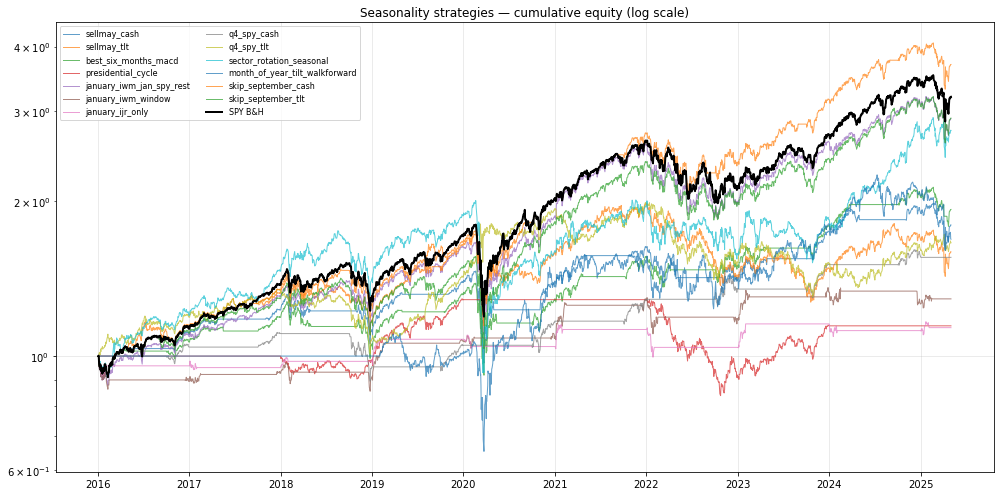

In [15]:
# Equity curves comparison
fig, ax = plt.subplots(figsize=(14, 7))
for name, (m, dr, eq, tr) in results.items():
    ax.plot(np.asarray(eq.index), np.asarray(eq.values), lw=1.0, alpha=0.7, label=name)
ax.plot(np.asarray(spy_eq.index), np.asarray(spy_eq.values), lw=2.0, color="black", label="SPY B&H")
ax.set_yscale("log")
ax.set_title("Seasonality strategies — cumulative equity (log scale)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Correlation matrix of daily returns
ret_df = pd.DataFrame({name: dr for name, (m, dr, eq, tr) in results.items()})
ret_df["SPY_BH"] = spy_ret

corr = ret_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("Daily-return correlation matrix")
plt.tight_layout(); plt.show()

In [ ]:
# Save final summary JSON
import json
out = {name: {k: (v if not isinstance(v, (np.floating, np.integer)) else float(v)) for k, v in m.items()}
       for name, (m, dr, eq, tr) in results.items()}
out["SPY_BH"] = {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) for k, v in spy_metrics.items()}
with open(OUT_DIR / "seasonality_summary.json", "w") as f:
    json.dump(out, f, indent=2, default=str)
summary_df.to_csv(OUT_DIR / "seasonality_summary.csv")
print(f"Saved: {OUT_DIR / 'seasonality_summary.json'}")
print(f"Saved: {OUT_DIR / 'seasonality_summary.csv'}")

---

## Findings template (fill after running)

**Strategies passing significance bar (Sharpe > 0.4, p < 0.10, MaxDD < SPY MaxDD):**
- _(populate)_

**Strategies failing — likely noise / underpowered:**
- _(populate)_

**Best diversifiers (low correlation with SPY):**
- _(populate)_

**Candidates for Portfolio C inclusion (re-validate on WRDS long sample):**
- _(populate)_